In [2]:
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
import time

# ==============================================================================
# 1. DEFINICIÓN DEL PROBLEMA (GAP)
# ==============================================================================
NUM_TASKS = 4
NUM_OPERATORS = 5

# Matriz de Costes (O x T)
COSTS = np.array([
    [ 2,  3,  4,  1], # O1
    [ 3,  2,  3,  2], # O2
    [ 2,  2,  1,  2], # O3
    [ 3,  3,  3,  3], # O4
    [ 2,  1,  2,  2]  # O5
])

# Tiempo requerido por tarea
REQ_TIMES = np.array([3, 2, 2, 3])

# Tiempo disponible por operario
TIME_AVAILABLE = np.array([4, 5, 3, 4, 4])

In [4]:
# ==============================================================================
# 2. CLASE HORMIGA (COMÚN PARA TODOS LOS ENFOQUES)
# ==============================================================================
class Ant:
    def __init__(self, ant_id=0, num_ants=1):
        self.assignment = [-1] * NUM_TASKS 
        self.operator_usage = np.zeros(NUM_OPERATORS)
        self.total_cost = 0.0
        self.is_valid = True
        
        # PROPIEDAD MAS: Lambda define la preferencia entre objetivos
        # 0 = Prioridad Equilibrio, 1 = Prioridad Coste
        if num_ants > 1:
            self.lambda_weight = ant_id / (num_ants - 1)
        else:
            self.lambda_weight = 0.5 

    def calculate_metrics(self):
        """Calcula Coste Total y uso de recursos."""
        self.total_cost = 0
        self.operator_usage = np.zeros(NUM_OPERATORS)
        
        for task_idx, op_idx in enumerate(self.assignment):
            if op_idx == -1:
                self.is_valid = False
                return
            self.total_cost += COSTS[op_idx][task_idx]
            self.operator_usage[op_idx] += REQ_TIMES[task_idx]

        # Validación de restricciones de tiempo
        if np.any(self.operator_usage > TIME_AVAILABLE):
            self.is_valid = False

    def get_load_imbalance(self):
        """
        Objetivo 2: Desviación Estándar (StdDev).
        Mide la dispersión de la carga de trabajo entre operarios.
        """
        return np.std(self.operator_usage)

# ==============================================================================
# 3. Algoritmo: MONO-OBJETIVO (Elitist Ant System)
#    Objetivo: Minimizar Coste
# ==============================================================================
class MonoObjectiveAS:
    def __init__(self, num_ants=20, rho=0.1, alpha=1, beta=2, q=100):
        self.num_ants = num_ants
        self.rho = rho
        self.alpha = alpha
        self.beta = beta
        self.Q = q
        self.pheromones = np.ones((NUM_OPERATORS, NUM_TASKS)) * 0.1
        self.heuristic = 1.0 / (COSTS + 1e-6)

    def select_operator(self, task_idx, current_usage):
        probs = []
        allowed = []
        for op in range(NUM_OPERATORS):
            if (TIME_AVAILABLE[op] - current_usage[op]) >= REQ_TIMES[task_idx]:
                tau = self.pheromones[op][task_idx]
                eta = self.heuristic[op][task_idx]
                probs.append((tau ** self.alpha) * (eta ** self.beta))
                allowed.append(op)
        
        if not allowed: return -1
        total = sum(probs)
        if total == 0: return random.choice(allowed)
        return random.choices(allowed, weights=[p/total for p in probs], k=1)[0]

    def run(self, generations=50):
        best_global = None
        for _ in range(generations):
            ants = []
            # Construcción
            for _ in range(self.num_ants):
                ant = Ant()
                for t in range(NUM_TASKS):
                    op = self.select_operator(t, ant.operator_usage)
                    if op == -1: 
                        ant.is_valid = False; break
                    ant.assignment[t] = op
                    ant.operator_usage[op] += REQ_TIMES[t]
                
                if ant.is_valid:
                    ant.calculate_metrics()
                    ants.append(ant)
                    if best_global is None or ant.total_cost < best_global.total_cost:
                        best_global = copy.deepcopy(ant)
            
            # Actualización Feromona (Evaporación + Aporte)
            self.pheromones *= (1 - self.rho)
            if best_global: # Estrategia Elitista
                dt = self.Q / best_global.total_cost
                for t, o in enumerate(best_global.assignment):
                    self.pheromones[o][t] += dt
        return best_global

# ==============================================================================
# 4. Algoritmo: MULTI-OBJETIVO BÁSICO (MOACO)
#    Objetivo: Coste y Equilibrio
# ==============================================================================
class SimpleMOACO:
    def __init__(self, num_ants=20, rho=0.1, alpha=1, beta=2):
        self.num_ants = num_ants
        self.rho = rho
        self.alpha = alpha
        self.beta = beta
        self.pheromones = np.ones((NUM_OPERATORS, NUM_TASKS)) * 0.1
        self.heuristic = 1.0 / (COSTS + 1e-6)

    def select_operator(self, task_idx, current_usage):
        # Usa la misma lógica que el mono-objetivo para construir
        probs = []
        allowed = []
        for op in range(NUM_OPERATORS):
            if (TIME_AVAILABLE[op] - current_usage[op]) >= REQ_TIMES[task_idx]:
                tau = self.pheromones[op][task_idx]
                eta = self.heuristic[op][task_idx]
                probs.append((tau ** self.alpha) * (eta ** self.beta))
                allowed.append(op)
        
        if not allowed: return -1
        total = sum(probs)
        if total == 0: return random.choice(allowed)
        return random.choices(allowed, weights=[p/total for p in probs], k=1)[0]

    def update_pareto(self, archive, new_sols):
        pool = archive + new_sols
        non_dominated = []
        for a in pool:
            dom = False
            for b in pool:
                if a == b: continue
                # Dominancia: Menor Coste Y Menor Desequilibrio
                if (b.total_cost <= a.total_cost and b.get_load_imbalance() <= a.get_load_imbalance()) and \
                   (b.total_cost < a.total_cost or b.get_load_imbalance() < a.get_load_imbalance()):
                    dom = True; break
            if not dom:
                if not any(np.array_equal(a.assignment, x.assignment) for x in non_dominated):
                    non_dominated.append(a)
        return non_dominated

    def run(self, generations=50):
        pareto = []
        for _ in range(generations):
            ants = []
            for _ in range(self.num_ants):
                ant = Ant()
                for t in range(NUM_TASKS):
                    op = self.select_operator(t, ant.operator_usage)
                    if op == -1: ant.is_valid = False; break
                    ant.assignment[t] = op
                    ant.operator_usage[op] += REQ_TIMES[t]
                if ant.is_valid:
                    ant.calculate_metrics()
                    ants.append(ant)
            
            pareto = self.update_pareto(pareto, ants)
            self.pheromones *= (1 - self.rho)
            # Solo el frente de Pareto deposita feromona
            for sol in pareto:
                dt = 100.0 / sol.total_cost
                for t, o in enumerate(sol.assignment):
                    self.pheromones[o][t] += dt
        return pareto

# ==============================================================================
# 5. Algoritmo MAS (Multi-Objective Ant System clase)
#    Usa Lambda para asignar mas peso al equilibrio o al coste
# ==============================================================================
class MAS:
    def __init__(self, num_ants=30, rho=0.1, alpha=1, beta=2):
        self.num_ants = num_ants
        self.rho = rho
        self.alpha = alpha
        self.beta = beta
        self.pheromones = np.ones((NUM_OPERATORS, NUM_TASKS)) * 0.1
        self.eta_cost = 1.0 / (COSTS + 1e-6)

    def get_dynamic_heuristic(self, task_idx, current_usage):
        # Heurística 2: Tiempo libre restante
        eta = np.zeros(NUM_OPERATORS)
        for op in range(NUM_OPERATORS):
            rem = TIME_AVAILABLE[op] - current_usage[op]
            eta[op] = rem if rem >= REQ_TIMES[task_idx] else 0.1
        return eta

    def select_operator(self, task_idx, current_usage, lambda_w):
        probs = []
        allowed = []
        eta_bal = self.get_dynamic_heuristic(task_idx, current_usage)
        
        for op in range(NUM_OPERATORS):
            if (TIME_AVAILABLE[op] - current_usage[op]) >= REQ_TIMES[task_idx]:
                tau = self.pheromones[op][task_idx]
                h1 = self.eta_cost[op][task_idx]
                h2 = eta_bal[op]
                # Regla de transición MAS con Lambda
                score = (tau ** self.alpha) * \
                        (h1 ** (lambda_w * self.beta)) * \
                        ((h2 + 1e-6) ** ((1 - lambda_w) * self.beta))
                probs.append(score)
                allowed.append(op)
        
        if not allowed: return -1
        total = sum(probs)
        if total == 0: return random.choice(allowed)
        return random.choices(allowed, weights=[p/total for p in probs], k=1)[0]
    
    def update_pareto(self, archive, new_sols):
        pool = archive + new_sols
        non_dominated = []
        for a in pool:
            dom = False
            for b in pool:
                if a == b: continue
                if (b.total_cost <= a.total_cost and b.get_load_imbalance() <= a.get_load_imbalance()) and \
                   (b.total_cost < a.total_cost or b.get_load_imbalance() < a.get_load_imbalance()):
                    dom = True; break
            if not dom:
                if not any(np.array_equal(a.assignment, x.assignment) for x in non_dominated):
                    non_dominated.append(a)
        return non_dominated

    def run(self, generations=50):
        pareto = []
        for _ in range(generations):
            ants = []
            for i in range(self.num_ants):
                # Usamos ID para generar Lambda
                ant = Ant(i, self.num_ants)
                for t in range(NUM_TASKS):
                    op = self.select_operator(t, ant.operator_usage, ant.lambda_weight)
                    if op == -1: ant.is_valid = False; break
                    ant.assignment[t] = op
                    ant.operator_usage[op] += REQ_TIMES[t]
                if ant.is_valid:
                    ant.calculate_metrics()
                    ants.append(ant)
            
            pareto = self.update_pareto(pareto, ants)
            current_pareto = self.update_pareto([], ants) # Solo de esta iteración
            
            self.pheromones *= (1 - self.rho)
            # Actualización MAS: 1 / Suma(Objetivos)
            for sol in current_pareto:
                denom = sol.total_cost + sol.get_load_imbalance()
                dt = 1.0 / (denom + 1e-6)
                for t, o in enumerate(sol.assignment):
                    self.pheromones[o][t] += dt
        return pareto

=== 1. Ejecutando Mono-Objetivo ===
-> Tiempo: 0.0298 seg
Mejor Solución: Coste 6, Asignación [0, 4, 2, 1]

=== 2. Ejecutando Multi-Objetivo Básico (MOACO) ===
-> Tiempo: 2.4211 seg
Soluciones en Frente: 4

--- Tabla de Soluciones (Simple MOACO) ---
Coste  StdDev   Asignación
----------------------------------------
6      1.0954   [1, 4, 2, 0]
6      1.0954   [0, 4, 2, 1]
6      1.0954   [4, 1, 2, 0]
6      1.0954   [3, 4, 2, 0]
----------------------------------------


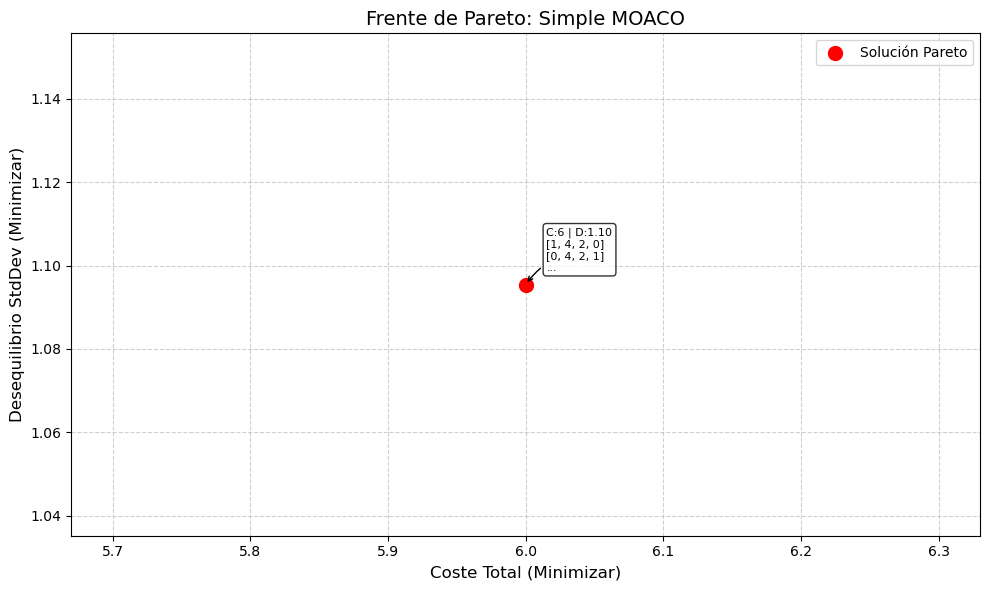


=== 3. Ejecutando MAS (Lambda Weights) ===
-> Tiempo: 2.9358 seg
Soluciones en Frente: 4

--- Tabla de Soluciones (MAS) ---
Coste  StdDev   Asignación
----------------------------------------
6      1.0954   [3, 4, 2, 0]
6      1.0954   [0, 4, 2, 1]
6      1.0954   [4, 1, 2, 0]
6      1.0954   [1, 4, 2, 0]
----------------------------------------


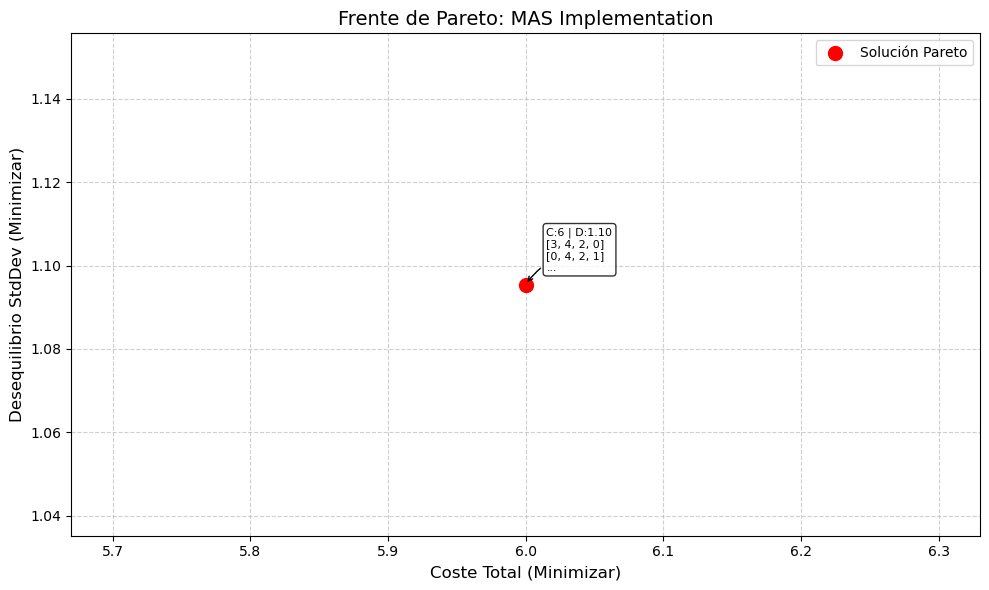

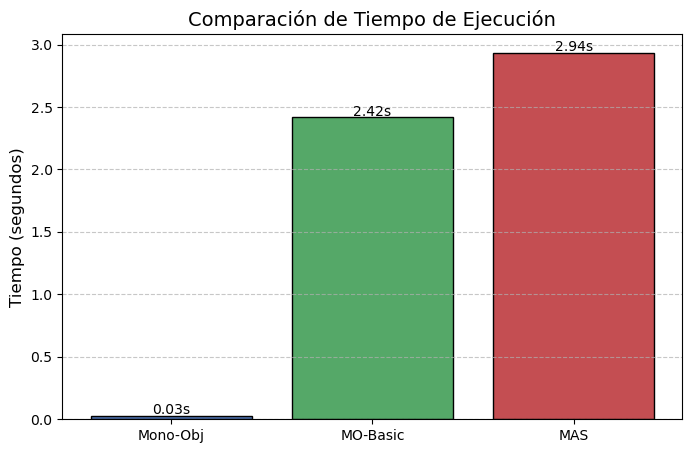

In [5]:
def plot_results(pareto_solutions, title):
    if not pareto_solutions:
        print(f"No hay soluciones para graficar en {title}")
        return

    # Agrupar puntos idénticos para visualización limpia
    points = {}
    for sol in pareto_solutions:
        coord = (sol.total_cost, sol.get_load_imbalance())
        if coord not in points: points[coord] = []
        points[coord].append(str(sol.assignment))
    
    costs = [k[0] for k in points.keys()]
    imbs = [k[1] for k in points.keys()]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(costs, imbs, c='red', s=100, zorder=2, label='Solución Pareto')
    plt.title(title, fontsize=14)
    plt.xlabel('Coste Total (Minimizar)', fontsize=12)
    plt.ylabel('Desequilibrio StdDev (Minimizar)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Anotaciones
    for coord, assigns in points.items():
        c, i = coord
        txt = f"C:{c} | D:{i:.2f}\n" + "\n".join(assigns[:2]) # Max 2 lineas
        if len(assigns) > 2: txt += "\n..."
        
        plt.annotate(txt, (c, i), xytext=(15, 10), textcoords='offset points',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
                     arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"),
                     fontsize=8)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 7. MAIN - EJECUCIÓN UNIFICADA
# ==============================================================================
if __name__ == "__main__":
    exec_times = {}
    
    # --- 1. Ejecución Mono-Objetivo ---
    print("=== 1. Ejecutando Mono-Objetivo ===")
    start_time = time.time()
    
    mono = MonoObjectiveAS(num_ants=20)
    best = mono.run(generations=30)
    
    end_time = time.time()
    exec_times['Mono-Obj'] = end_time - start_time
    print(f"-> Tiempo: {exec_times['Mono-Obj']:.4f} seg")
    
    if best:
        print(f"Mejor Solución: Coste {best.total_cost}, Asignación {best.assignment}")
    else:
        print("No se encontró solución válida.")

    # --- 2. Ejecución Multi-Objetivo ---
    print("\n=== 2. Ejecutando Multi-Objetivo Básico (MOACO) ===")
    start_time = time.time()
    
    simple = SimpleMOACO(num_ants=30)
    pareto_simple = simple.run(generations=50)
    
    end_time = time.time()
    exec_times['MO-Basic'] = end_time - start_time
    print(f"-> Tiempo: {exec_times['MO-Basic']:.4f} seg")
    print(f"Soluciones en Frente: {len(pareto_simple)}")
    
    # Imprimir
    pareto_simple.sort(key=lambda x: x.total_cost)
    print("\n--- Tabla de Soluciones (Simple MOACO) ---")
    print(f"{'Coste':<6} {'StdDev':<8} {'Asignación'}")
    print("-" * 40)
    for p in pareto_simple:
        print(f"{p.total_cost:<6} {p.get_load_imbalance():<8.4f} {p.assignment}")
    print("-" * 40)
    
    plot_results(pareto_simple, "Frente de Pareto: Simple MOACO")

    # --- 3. Ejecución MAS ---
    print("\n=== 3. Ejecutando MAS (Lambda Weights) ===")
    start_time = time.time()
    
    mas = MAS(num_ants=30)
    pareto_mas = mas.run(generations=50)
    
    end_time = time.time()
    exec_times['MAS'] = end_time - start_time
    print(f"-> Tiempo: {exec_times['MAS']:.4f} seg")
    print(f"Soluciones en Frente: {len(pareto_mas)}")
    
    # Imprimir
    pareto_mas.sort(key=lambda x: x.total_cost)
    print("\n--- Tabla de Soluciones (MAS) ---")
    print(f"{'Coste':<6} {'StdDev':<8} {'Asignación'}")
    print("-" * 40)
    for p in pareto_mas:
        print(f"{p.total_cost:<6} {p.get_load_imbalance():<8.4f} {p.assignment}")
    print("-" * 40)
        
    plot_results(pareto_mas, "Frente de Pareto: MAS Implementation")

    # --- 4. Gráfica Comparativa de Tiempos ---
    plt.figure(figsize=(8, 5))
    algos = list(exec_times.keys())
    tiempos = list(exec_times.values())
    colors = ['#4c72b0', '#55a868', '#c44e52']

    plt.bar(algos, tiempos, color=colors, edgecolor='black')
    plt.title('Comparación de Tiempo de Ejecución', fontsize=14)
    plt.ylabel('Tiempo (segundos)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(tiempos):
        plt.text(i, v + 0.01, f"{v:.2f}s", ha='center', fontsize=10)
        
    plt.show()

# Figuras para la memoria: *ocultar*

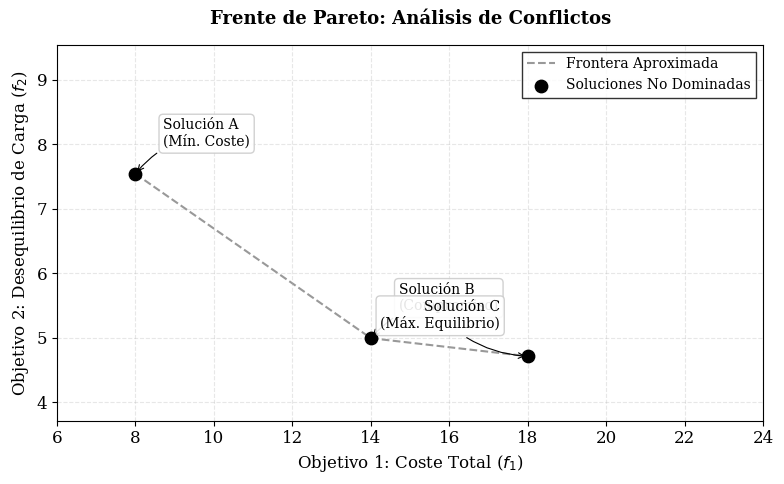

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos nuevos
sol_a = {'cost': 8, 'imbalance': 7.54, 'label': 'Solución A\n(Mín. Coste)'}
sol_b = {'cost': 14, 'imbalance': 4.99, 'label': 'Solución B\n(Compromiso)'}
sol_c = {'cost': 18, 'imbalance': 4.71, 'label': 'Solución C\n(Máx. Equilibrio)'}

pareto_front = [sol_a, sol_b, sol_c]
costs = [s['cost'] for s in pareto_front]
imbalances = [s['imbalance'] for s in pareto_front]
labels = [s['label'] for s in pareto_front]

# Estilo gráfica
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(costs, imbalances, color='#555555', linestyle='--', alpha=0.6, zorder=1, label='Frontera Aproximada')
ax.scatter(costs, imbalances, color='black', marker='o', s=80, zorder=2, label='Soluciones No Dominadas')
for i, txt in enumerate(labels):
    offset = (20, 20) if i < 2 else (-20, 20)
    align = 'left' if i < 2 else 'right'
    
    ax.annotate(txt, 
                xy=(costs[i], imbalances[i]), 
                xytext=offset,
                textcoords='offset points',
                ha=align,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='black', lw=0.8),
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.9)) # Caja blanca limpia

ax.set_xlabel(r'Objetivo 1: Coste Total ($f_1$)', fontsize=12)
ax.set_ylabel(r'Objetivo 2: Desequilibrio de Carga ($f_2$)', fontsize=12)
ax.set_title('Frente de Pareto: Análisis de Conflictos', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(min(costs)-2, max(costs)+6)
ax.set_ylim(min(imbalances)-1, max(imbalances)+2)

# Leyenda
ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=10)

# Guardar gráfica
plt.tight_layout()
plt.savefig('./ants_results.pdf')
plt.show()

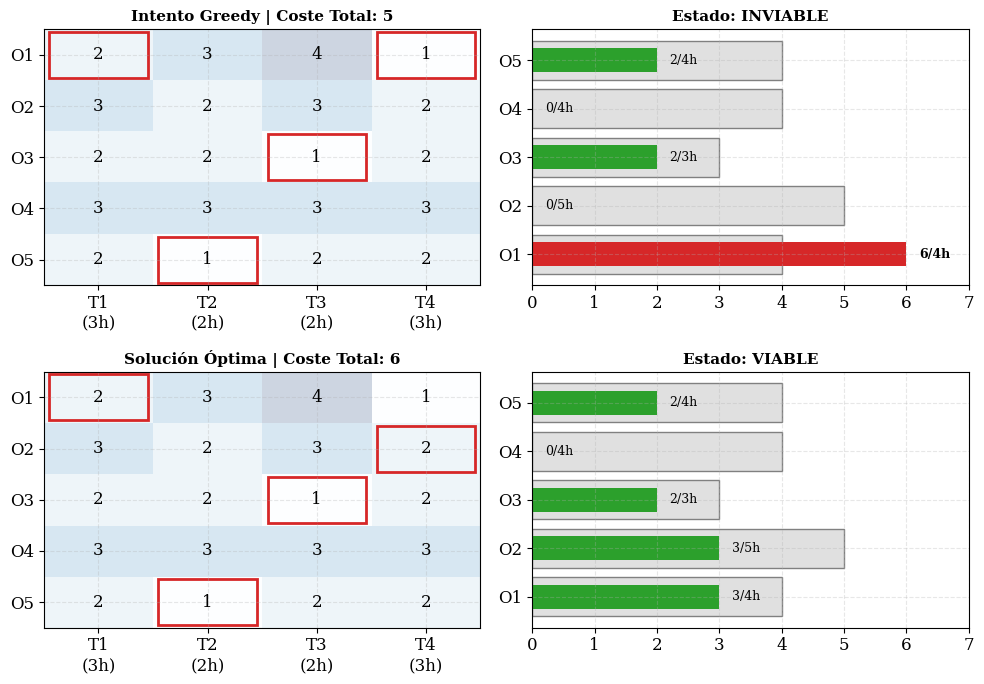

In [12]:
# Gráfico para explicar solución mínima = 6, sol greedy = 5 es imposible

# Datos
COSTS = np.array([
    [2, 3, 4, 1], # O1
    [3, 2, 3, 2], # O2
    [2, 2, 1, 2], # O3
    [3, 3, 3, 3], # O4
    [2, 1, 2, 2]  # O5
])
#Tiempos tareas
REQ_TIMES = np.array([3, 2, 2, 3])
#Operadores
AVAIL_TIMES = np.array([4, 5, 3, 4, 4]) # O1...O5

# --- 2. ESCENARIOS ---

# A) Escenario Greedy
ideal_assign = [(0, 0), (4, 1), (2, 2), (0, 3)] 
ideal_loads = np.zeros(5)
for op, task in ideal_assign: ideal_loads[op] += REQ_TIMES[task]

# B) Escenario Óptimo
real_assign = [(0, 0), (4, 1), (2, 2), (1, 3)]
real_loads = np.zeros(5)
for op, task in real_assign: real_loads[op] += REQ_TIMES[task]

#Gráfica
plt.rcParams['font.family'] = 'serif'
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

def plot_scenario(row_idx, assign, loads, title_matrix, title_bars):
    ax = axes[row_idx, 0]
    ax.imshow(COSTS, cmap='Blues', aspect='auto', alpha=0.2)
    ax.set_xticks(range(4)); ax.set_xticklabels([f'T{i+1}\n({REQ_TIMES[i]}h)' for i in range(4)])
    ax.set_yticks(range(5)); ax.set_yticklabels([f'O{i+1}' for i in range(5)])
    
    for i in range(5):
        for j in range(4):
            ax.text(j, i, COSTS[i, j], ha='center', va='center', color='black')
    
    cost = 0
    for op, task in assign:
        rect = patches.Rectangle((task-0.45, op-0.45), 0.9, 0.9, lw=2, edgecolor='#d62728', facecolor='none')
        ax.add_patch(rect)
        cost += COSTS[op, task]
    ax.set_title(f"{title_matrix} | Coste Total: {cost}", fontweight='bold', fontsize=11)

    ax2 = axes[row_idx, 1]
    y_pos = np.arange(5)
    ax2.barh(y_pos, AVAIL_TIMES, color='#e0e0e0', edgecolor='gray', label='Capacidad Disp.')
    cols = ['#2ca02c' if l <= c else '#d62728' for l, c in zip(loads, AVAIL_TIMES)]
    ax2.barh(y_pos, loads, color=cols, height=0.5, label='Carga Asignada')
    ax2.set_yticks(y_pos); ax2.set_yticklabels([f'O{i+1}' for i in range(5)])
    ax2.set_xlim(0, 7) # Margen fijo
    ax2.set_title(title_bars, fontweight='bold', fontsize=11)

    for i, (l, c) in enumerate(zip(loads, AVAIL_TIMES)):
        ax2.text(l+0.2, i, f"{int(l)}/{c}h", va='center', fontsize=9, fontweight=('bold' if l>c else 'normal'))

plot_scenario(0, ideal_assign, ideal_loads, "Intento Greedy", "Estado: INVIABLE")
plot_scenario(1, real_assign, real_loads, "Solución Óptima", "Estado: VIABLE")

plt.tight_layout()
plt.savefig("./explicacion_sol_ants.pdf")
plt.show()